# Module 5 — Model Figure (Branching Regimes)

This notebook reproduces the **model-only figure** by loading the three regime outputs (log, simple, exp/singularity).

Before running, compile and execute `modelling_micro_macro_branching.c` in three modes (0, 1, 2) to generate the input files in `dati/`.


## Imports and base paths

Set `base_dir` to the project root and locate the `dati/` folder used by the C program.


In [1]:
# Imports and paths
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from pathlib import Path

points = 18
point_size = 10  # Dimensione dei punti
line_width = 5  # Spessore delle linee

# Ingrandisci il font
plt.rcParams['font.size'] = 28
plt.rcParams['axes.labelsize'] = 30
plt.rcParams['xtick.labelsize'] = 28
plt.rcParams['ytick.labelsize'] = 28

data_dir = Path("data_simulations")


## Load the three regimes

We read the two files per regime:
- `UMT_<label>_rho=..._nu=...dat`
- `n_UMT_<label>_rho=..._nu=...dat`


In [2]:
# Load model outputs for the three regimes
regimes = {
    "log": "log",
    "simple": "simple_branching",
    "singularity": "singularity",
}

rho = 1.0
nu = 1.0

data = {}

for reg, label in regimes.items():
    mode = 0 if reg == "log" else (1 if reg == "simple" else 2)
    filename = data_dir / f"model_{label}_mode={mode}_rho={rho:.1f}_nu={nu:.1f}.dat"
    arr = np.loadtxt(filename)

    tau = arr[:, 0]
    t = arr[:, 1] + 1
    D = arr[:, 2] + 1
    w = arr[:, 3] + 1

    filename_freq = data_dir / f"n_model_{label}_mode={mode}_rho={rho:.1f}_nu={nu:.1f}.dat"
    arr_f = np.loadtxt(filename_freq)
    freq = arr_f[:, 1]
    freq_sorted = np.sort(freq)[::-1]
    rank = np.arange(1, len(freq_sorted) + 1)

    data[reg] = {
        "tau": tau,
        "t": t,
        "D_t": D,
        "w_t": w,
        "D_tau": D,
        "w_tau": w,
        "rank": rank,
        "freq": freq_sorted,
    }


## Plot the model figure

This reproduces the 2×3 panel from `figures/figures_model.ipynb` (first cell only).


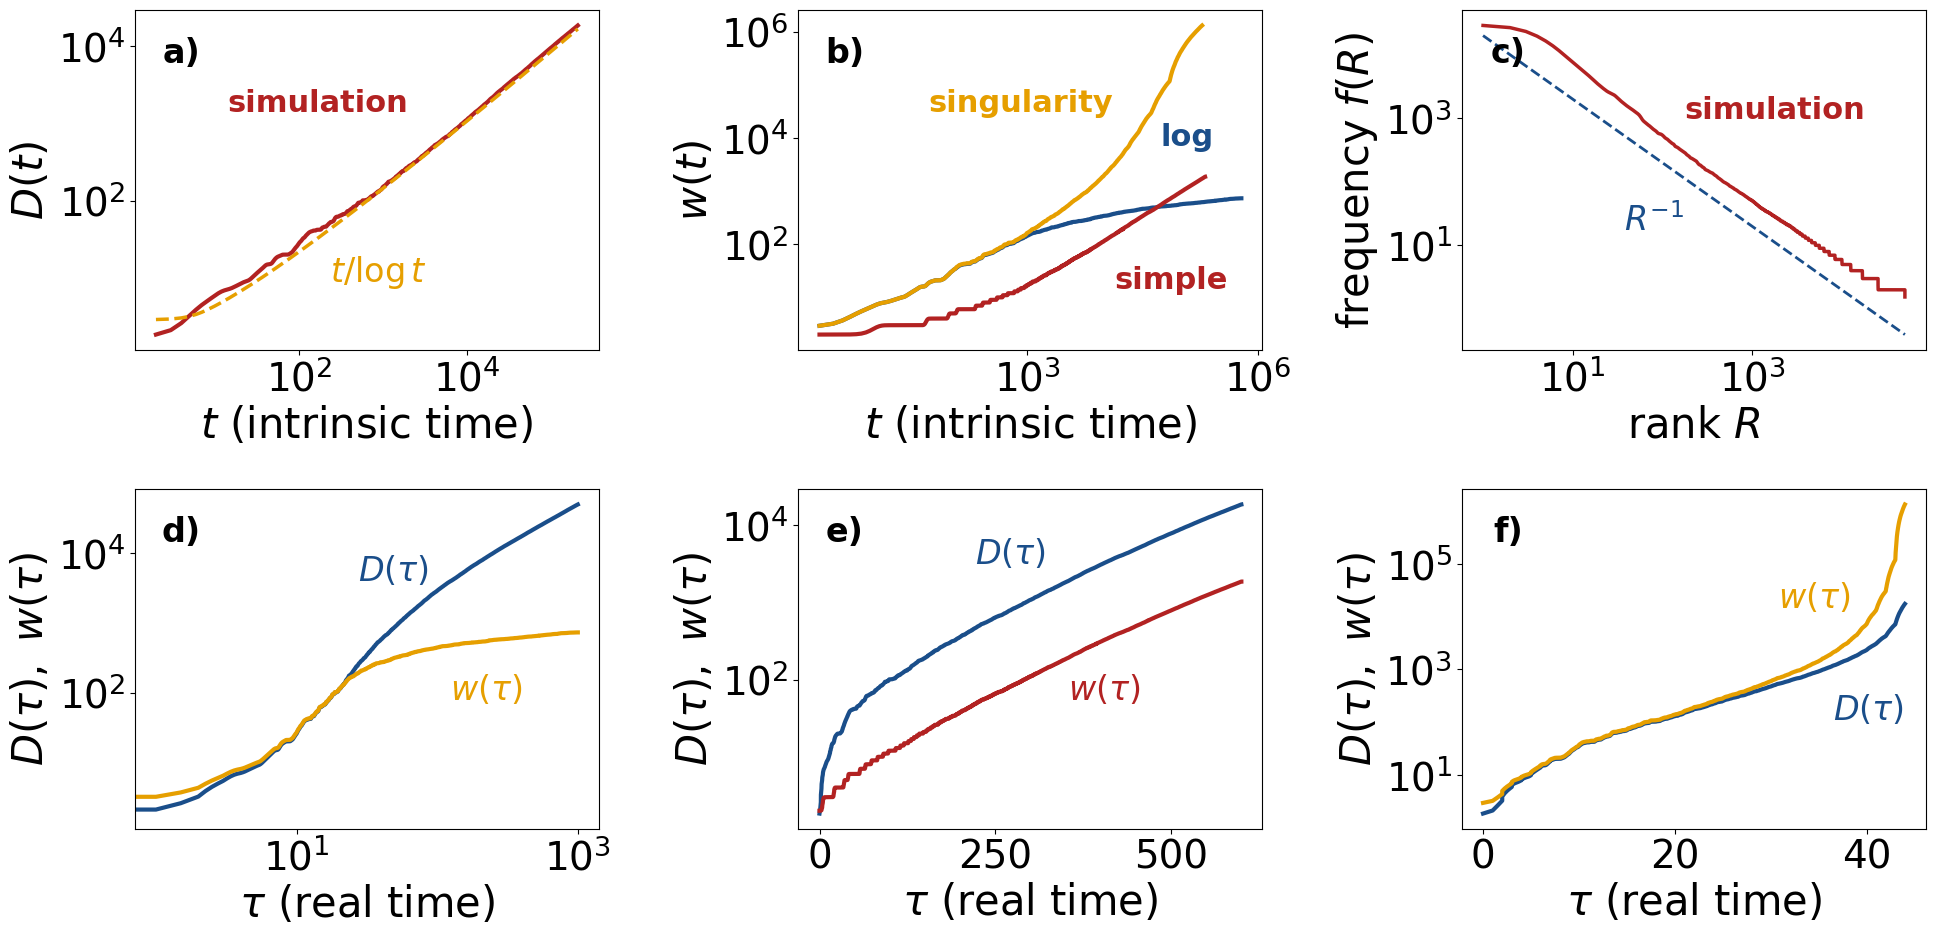

In [3]:
# Plot the 2x3 model figure
colors = ["#1A4E8A", "#B22222", "#E69F00"]

# Smooth in log space to avoid sharp steps

def smooth_logy(y, sigma=2):
    y = np.asarray(y)
    y = np.clip(y, 1e-12, None)
    return 10**gaussian_filter1d(np.log10(y), sigma=sigma)

rank = data["log"]["rank"]
freq = data["log"]["freq"]

fig, axs = plt.subplots(2, 3, figsize=(20, 10))

# (a) D(t) — intrinsic time, simple regime
ax = axs[0, 0]
regime = "simple"
y_sim = smooth_logy(data[regime]["D_t"])
y_ref = smooth_logy(data[regime]["t"] / np.log(data[regime]["t"]))
ax.plot(data[regime]["t"], y_sim, lw=3, color=colors[1])
ax.plot(data[regime]["t"], y_ref, ls='--', lw=2.5, color=colors[2])
ax.set_xlabel(r"$t$ (intrinsic time)")
ax.set_ylabel(r"$D(t)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.text(0.1, 0.92, "a)", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, fontweight="bold")
ax.text(0.20, 0.7, "simulation", transform=ax.transAxes, color=colors[1],
        fontsize=22, fontweight="bold")
ax.text(0.42, 0.2, r"$t/\log t$", transform=ax.transAxes, color=colors[2],
        fontsize=24, fontweight="bold")

# (b) w(t) — number of authors
ax = axs[0, 1]
for i, regime in enumerate(regimes):
    y_sm = smooth_logy(data[regime]["w_t"])
    ax.plot(data[regime]["t"], y_sm, lw=3, color=colors[i])
ax.set_xlabel(r"$t$ (intrinsic time)")
ax.set_ylabel(r"$w(t)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.text(0.1, 0.92, "b)", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, fontweight="bold")
ax.text(0.78, 0.60, "log", transform=ax.transAxes, color=colors[0],
        fontsize=22, fontweight="bold")
ax.text(0.68, 0.18, "simple", transform=ax.transAxes, color=colors[1],
        fontsize=22, fontweight="bold")
ax.text(0.28, 0.7, "singularity", transform=ax.transAxes, color=colors[2],
        fontsize=22, fontweight="bold")

# (c) Rank–Frequency
ax = axs[0, 2]
freq_sm = smooth_logy(freq + 1)
ax.loglog(rank, freq_sm, lw=2.5, color=colors[1])
ax.loglog(rank, rank**(-1.) * 10**4.3, ls='--', lw=2, color=colors[0])
ax.set_xlabel(r"rank $R$")
ax.set_ylabel(r"frequency $f(R)$")
ax.text(0.1, 0.92, "c)", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, fontweight="bold")
ax.text(0.48, 0.68, "simulation", transform=ax.transAxes, color=colors[1],
        fontsize=22, fontweight="bold")
ax.text(0.35, 0.35, r"$R^{-1}$", transform=ax.transAxes, color=colors[0],
        fontsize=24, fontweight="bold")

# (d) Log regime: D(τ) and w(τ)
ax = axs[1, 0]
reg = "log"
ax.plot(data[reg]["tau"], smooth_logy(data[reg]["D_tau"]), lw=3, color=colors[0])
ax.plot(data[reg]["tau"], smooth_logy(data[reg]["w_tau"]), lw=3, color=colors[2])
ax.set_xlabel(r"$\tau$ (real time)")
ax.set_ylabel(r"$D(\tau), \ w(\tau)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.text(0.1, 0.92, "d)", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, fontweight="bold")
ax.text(0.48, 0.73, r"$D(\tau)$", transform=ax.transAxes, color=colors[0],
        fontsize=24, fontweight="bold")
ax.text(0.68, 0.38, r"$w(\tau)$", transform=ax.transAxes, color=colors[2],
        fontsize=24, fontweight="bold")

# (e) Simple regime: D(τ) and w(τ)
ax = axs[1, 1]
reg = "simple"
ax.plot(data[reg]["tau"], smooth_logy(data[reg]["D_tau"]), lw=3, color=colors[0])
ax.plot(data[reg]["tau"], smooth_logy(data[reg]["w_tau"]), lw=3, color=colors[1])
ax.set_xlabel(r"$\tau$ (real time)")
ax.set_ylabel(r"$D(\tau), \ w(\tau)$")
ax.set_yscale("log")
ax.text(0.1, 0.92, "e)", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, fontweight="bold")
ax.text(0.38, 0.78, r"$D(\tau)$", transform=ax.transAxes, color=colors[0],
        fontsize=24, fontweight="bold")
ax.text(0.58, 0.38, r"$w(\tau)$", transform=ax.transAxes, color=colors[1],
        fontsize=24, fontweight="bold")

# (f) Exp regime: D(τ) and w(τ)
ax = axs[1, 2]
reg = "singularity"
ax.plot(data[reg]["tau"], smooth_logy(data[reg]["D_tau"]), lw=3, color=colors[0])
ax.plot(data[reg]["tau"], smooth_logy(data[reg]["w_tau"]), lw=3, color=colors[2])
ax.set_yscale("log")
ax.set_xlabel(r"$\tau$ (real time)")
ax.set_ylabel(r"$D(\tau), \ w(\tau)$")
ax.text(0.1, 0.92, "f)", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, fontweight="bold")
ax.text(0.8, 0.32, r"$D(\tau)$", transform=ax.transAxes, color=colors[0],
        fontsize=24, fontweight="bold")
ax.text(0.68, 0.65, r"$w(\tau)$", transform=ax.transAxes, color=colors[2],
        fontsize=24, fontweight="bold")

plt.tight_layout()
plt.show()
